In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/


In [4]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
dogsvscats.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogsvscats.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [6]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

In [7]:
# generators
train_ds=keras.utils.image_dataset_from_directory(
    directory='/content/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

validation_ds=keras.utils.image_dataset_from_directory(
    directory='/content/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [8]:
# Normalize
def process(image, label):
  image=tf.cast(image/255. , tf.float32)
  return image, label

train_ds=train_ds.map(process)
validation_ds=validation_ds.map(process)

In [9]:
#create CNN model

model=Sequential()
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [12]:
history=model.fit(train_ds, epochs=20, validation_data=validation_ds)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 97ms/step - accuracy: 0.5605 - loss: 1.4187 - val_accuracy: 0.6542 - val_loss: 0.6303
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.6442 - loss: 0.6295 - val_accuracy: 0.6826 - val_loss: 0.5915
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.7125 - loss: 0.5643 - val_accuracy: 0.7046 - val_loss: 0.5705
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.7607 - loss: 0.4983 - val_accuracy: 0.7270 - val_loss: 0.5443
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 95ms/step - accuracy: 0.7916 - loss: 0.4461 - val_accuracy: 0.8060 - val_loss: 0.4421
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 97ms/step - accuracy: 0.8188 - loss: 0.4101 - val_accuracy: 0.8178 - val_loss: 0.3967
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.8422 - loss: 0.3560 - val_accuracy: 0.6266 - val_loss: 1.5010
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 95ms/step - accuracy: 0.8628 - loss: 0.3130 - 

In [16]:
model.save("dogs_vs_cats.keras")

In [17]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'dogs_vs_cats.keras', 'dogsvscats.zip', 'train', 'dogs_vs_cats.tflite', '.ipynb_checkpoints', 'test', 'catsvsdogs', 'kaggle.json', 'sample_data']


In [18]:
def representative_dataset():
    for images, _ in train_ds.take(100):
        yield [images]

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

with open("dogs_vs_cats_int8.tflite", "wb") as f:
    f.write(tflite_model)

print("INT8 TensorFlow Lite model created successfully!")

Saved artifact at '/tmp/tmpuz6w0el4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132220247332560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132220247333136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132220247333904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132220247334288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132220247331216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132220247332368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132220247333712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132220247335440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132220247335824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132220247336976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13222024733563

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INT8 TensorFlow Lite model created successfully!


In [19]:
import os

print("Keras model size:",
      os.path.getsize("dogs_vs_cats.keras") / (1024 * 1024), "MB")

print("INT8 TFLite model size:",
      os.path.getsize("dogs_vs_cats_int8.tflite") / (1024 * 1024), "MB")

Keras model size: 169.98956775665283 MB
INT8 TFLite model size: 14.178085327148438 MB


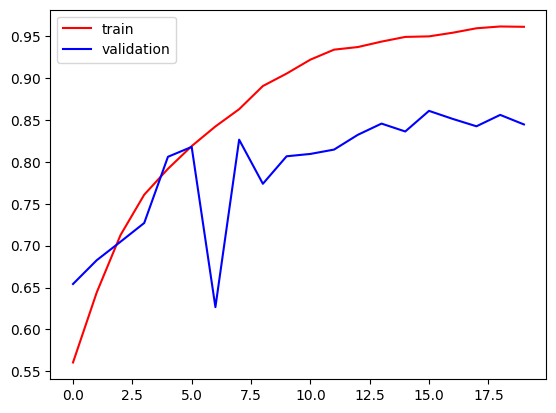

In [20]:

import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()
#

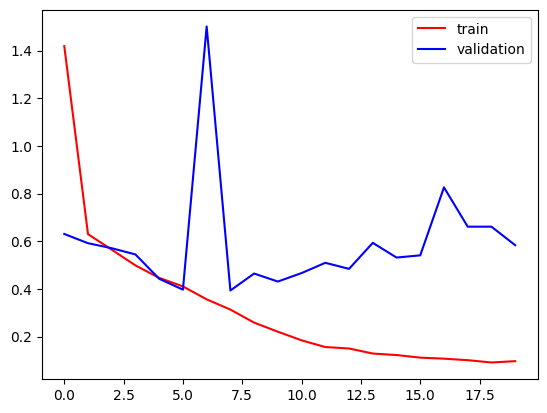

In [21]:

plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()

In [22]:
import cv2
import numpy as np
test_img = cv2.imread('/content/dog.jpg')
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
test_img = cv2.resize(test_img,(256,256))
test_img = test_img/255.0

test_input = np.expand_dims(test_img,axis=0)

prediction = model.predict(test_input)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[[0.9993975]]


In [24]:

test_img = cv2.imread('/content/cat.jpg')
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
test_img = cv2.resize(test_img,(256,256))
test_img = test_img/255.0

test_input = np.expand_dims(test_img,axis=0)

prediction = model.predict(test_input)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[[0.35371342]]


In [25]:
model.evaluate(validation_ds)

157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.8446 - loss: 0.5833


[0.5833156704902649, 0.8446000218391418]

In [26]:
import numpy as np

count = 0

for images, labels in validation_ds.take(1):
    predictions = model.predict(images)

    for i in range(10):
        print("----------------")
        print("Actual Label :", labels[i].numpy())
        print("Prediction   :", predictions[i][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step
----------------
Actual Label : 1
Prediction   : 0.9999999
----------------
Actual Label : 0
Prediction   : 0.9030339
----------------
Actual Label : 1
Prediction   : 0.9999789
----------------
Actual Label : 0
Prediction   : 0.0012103544
----------------
Actual Label : 1
Prediction   : 0.4315894
----------------
Actual Label : 0
Prediction   : 4.781005e-05
----------------
Actual Label : 0
Prediction   : 0.00456456
----------------
Actual Label : 0
Prediction   : 4.209884e-15
----------------
Actual Label : 1
Prediction   : 0.99999905
----------------
Actual Label : 0
Prediction   : 0.0019072782


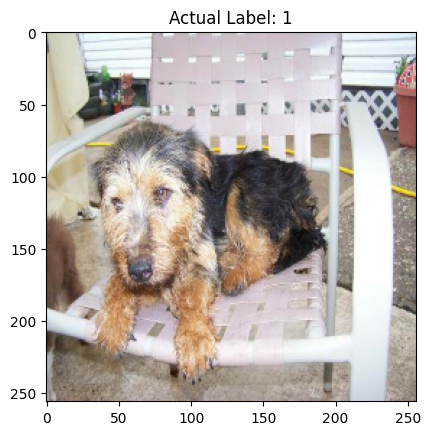

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Prediction: 0.8315148


In [27]:
import matplotlib.pyplot as plt

for images, labels in validation_ds.take(1):
    for i in range(32):
        if labels[i] == 1:   # Dog
            plt.imshow(images[i])
            plt.title(f"Actual Label: {labels[i].numpy()}")
            plt.show()

            pred = model.predict(tf.expand_dims(images[i], axis=0))
            print("Prediction:", pred[0][0])
            break

In [28]:
temp_ds = keras.utils.image_dataset_from_directory(
    directory='/content/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

print(temp_ds.class_names)

Found 5000 files belonging to 2 classes.
['cats', 'dogs']


In [29]:
print(labels[:10].numpy())

[0 0 0 1 0 0 1 1 0 1]


In [30]:
print(predictions[:10])

[[9.9999988e-01]
 [9.0303391e-01]
 [9.9997890e-01]
 [1.2103544e-03]
 [4.3158939e-01]
 [4.7810048e-05]
 [4.5645600e-03]
 [4.2098842e-15]
 [9.9999905e-01]
 [1.9072782e-03]]


In [31]:
print(len(history.history['accuracy']))

20


In [32]:
model.save("dogs_vs_cats_v1.keras")

In [35]:
prediction = model.predict(test_input)

print(prediction)
print(prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[0.35371342]]
0.35371342


In [34]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,543,685 (169.92 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 29,695,492 (113.28 MB)

None
